In [22]:
import os
import subprocess
import tifffile as tiff

# -------------------------
# Ilastik executable
# -------------------------
ILASTIK_PATH = "/Users/fmaurelia/Downloads/ilastik-1.4.2-arm64-OSX.app/Contents/MacOS/ilastik"

# -------------------------
# Base paths
# -------------------------
BASE_DIR = "/Users/fmaurelia/Library/CloudStorage/OneDrive-UniversitéClermontAuvergne/PHD/Github repository"

DATA_DIR = os.path.join(BASE_DIR, "data sample")
ILASTIK_DIR = os.path.join(BASE_DIR, "Ilastik")
OUTPUT_DIR = os.path.join(BASE_DIR, "demo results")
TMP_DIR = os.path.join(BASE_DIR, "tmp_slices")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TMP_DIR, exist_ok=True)

# -------------------------
# Environment
# -------------------------
env = os.environ.copy()
env["MPLBACKEND"] = "agg"

# -------------------------
# Embryos
# -------------------------
embryos = ["E1", "E2", "E3"]

# -------------------------
# Run Ilastik for CELLMASK
# -------------------------
for embryo in embryos:

    print(f"\n===== {embryo} → CELLMASK =====")

    cellmask_file = os.path.join(DATA_DIR, f"{embryo}_cellmask_subset.tif")
    cellmask_project = os.path.join(ILASTIK_DIR, f"{embryo} cellmask.ilp")

    if not os.path.exists(cellmask_file):
        raise FileNotFoundError(f"Missing input file: {cellmask_file}")

    if not os.path.exists(cellmask_project):
        raise FileNotFoundError(f"Missing ilastik project: {cellmask_project}")

    stack = tiff.imread(cellmask_file)

    print(f"{embryo} stack shape: {stack.shape}")

    for z in range(stack.shape[0]):

        print(f"{embryo} → z={z}")

        slice_img = stack[z]

        input_path = os.path.join(TMP_DIR, f"{embryo}_cellmask_z{z}.tif")
        out_path = os.path.join(OUTPUT_DIR, f"{embryo}_cellmask_z{z}_Probabilities.tif")

        tiff.imwrite(input_path, slice_img)

        cmd = [
            ILASTIK_PATH,
            "--headless",
            f"--project={cellmask_project}",
            "--export_source=Probabilities",
            "--output_format=tif",
            "--input_axes=yx",
            f"--output_filename_format={out_path}",
            input_path
        ]

        result = subprocess.run(
            cmd,
            env=env,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )

        if result.returncode != 0:
            print("   ❌ FAILED → debugging...")

            result_debug = subprocess.run(
                cmd,
                env=env,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True
            )

            print("STDERR:\n", result_debug.stderr)
            raise RuntimeError(f"Cellmask failed at {embryo} z={z}")

        print("   ✅ done")

print("\n✅ All cellmask probability maps exported successfully.")


===== E1 → CELLMASK =====
E1 stack shape: (4, 1920, 1920)
E1 → z=0
   ✅ done
E1 → z=1
   ✅ done
E1 → z=2
   ✅ done
E1 → z=3
   ✅ done

===== E2 → CELLMASK =====
E2 stack shape: (4, 1920, 1920)
E2 → z=0
   ✅ done
E2 → z=1
   ✅ done
E2 → z=2
   ✅ done
E2 → z=3
   ✅ done

===== E3 → CELLMASK =====
E3 stack shape: (4, 1920, 1920)
E3 → z=0
   ✅ done
E3 → z=1
   ✅ done
E3 → z=2
   ✅ done
E3 → z=3
   ✅ done

✅ All cellmask probability maps exported successfully.


In [10]:
import os
import subprocess
import tifffile as tiff

ILASTIK_PATH = "/Users/fmaurelia/Downloads/ilastik-1.4.2-arm64-OSX.app/Contents/MacOS/ilastik"

BASE_DIR = "/Users/fmaurelia/Library/CloudStorage/OneDrive-UniversitéClermontAuvergne/PHD/Github repository"

DATA_DIR = os.path.join(BASE_DIR, "data sample")
ILASTIK_DIR = os.path.join(BASE_DIR, "Ilastik")
OUTPUT_DIR = os.path.join(BASE_DIR, "demo results")
TMP_DIR = os.path.join(BASE_DIR, "tmp_slices")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(TMP_DIR, exist_ok=True)

env = os.environ.copy()
env["MPLBACKEND"] = "agg"

embryos = ["E1", "E2", "E3"]

for embryo in embryos:

    print(f"\n===== {embryo} → PHALLO =====")

    phallo_file = os.path.join(DATA_DIR, f"{embryo}_phalloidin_subset.tif")
    phallo_project = os.path.join(ILASTIK_DIR, f"{embryo} phalloidin.ilp")

    stack = tiff.imread(phallo_file)

    for z in range(stack.shape[0]):

        print(f"{embryo} → z={z}")

        slice_path = os.path.join(TMP_DIR, f"{embryo}_phallo_z{z}.tif")
        out_path = os.path.join(OUTPUT_DIR, f"{embryo}_phallo_z{z}_Probabilities.tif")

        tiff.imwrite(slice_path, stack[z])

        cmd = [
            ILASTIK_PATH,
            "--headless",
            f"--project={phallo_project}",
            "--export_source=Probabilities",
            "--output_format=tif",
            "--input_axes=yx",
            f"--output_filename_format={out_path}",
            slice_path
        ]

        subprocess.run(
            cmd,
            env=env,
            check=True,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )

        print("   ✅ done")



===== E1 → PHALLO =====
E1 → z=0
   ✅ done
E1 → z=1
   ✅ done
E1 → z=2
   ✅ done
E1 → z=3
   ✅ done

===== E2 → PHALLO =====
E2 → z=0
   ✅ done
E2 → z=1
   ✅ done
E2 → z=2
   ✅ done
E2 → z=3
   ✅ done

===== E3 → PHALLO =====
E3 → z=0
   ✅ done
E3 → z=1
   ✅ done
E3 → z=2
   ✅ done
E3 → z=3
   ✅ done


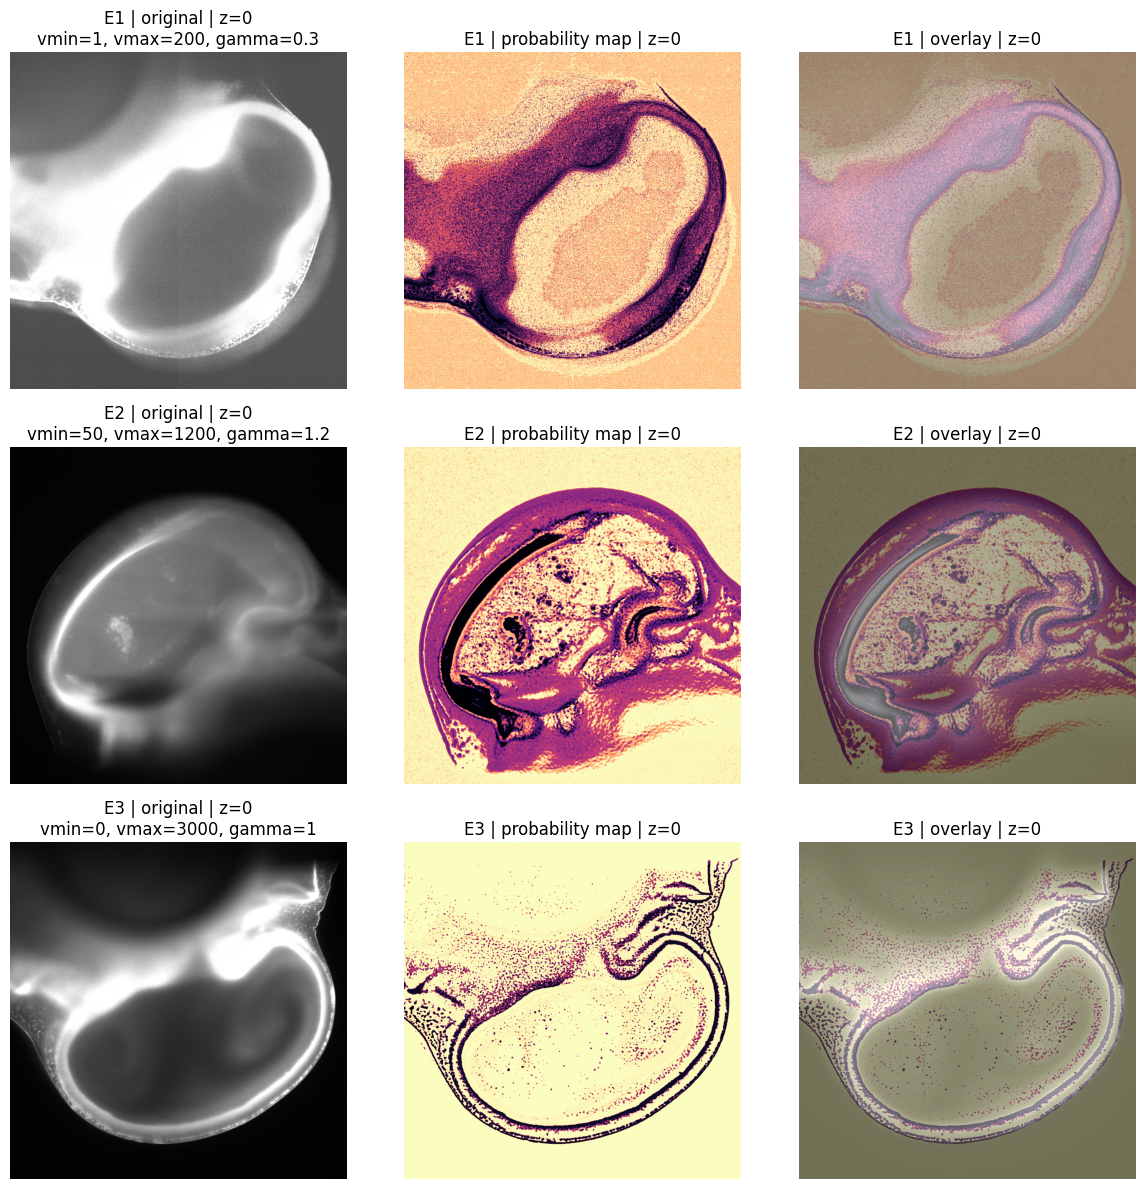

In [32]:
import os
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

# =========================================================
# CHOOSE WHICH RESULT TO DISPLAY
# "cellmask" or "phallo"
# =========================================================
channel = "cellmask"   # change to "phallo" if needed

# =========================================================
# ONE Z PER EMBRYO
# =========================================================
z_to_show = {
    "E1": 0,
    "E2": 0,
    "E3": 0,
}

# =========================================================
# DISPLAY SETTINGS FOR THE ORIGINAL IMAGE (PER EMBRYO)
# Adjust these values manually
# =========================================================
display_settings = {
    "E1": {"vmin": 1, "vmax": 200, "gamma": 0.3},
    "E2": {"vmin": 50, "vmax": 1200, "gamma": 1.2},
    "E3": {"vmin": 0, "vmax": 3000, "gamma": 1},
}

# =========================================================
# HELPER: contrast + gamma adjustment
# =========================================================
def adjust_image(img, vmin, vmax, gamma=1.0):
    img = img.astype(np.float32)
    img = np.clip(img, vmin, vmax)
    img = (img - vmin) / (vmax - vmin + 1e-8)
    img = np.power(img, gamma)
    return img

# =========================================================
# HELPER: get raw file and probability file
# =========================================================
def get_paths(embryo, channel, z):
    if channel == "cellmask":
        raw_file = os.path.join(DATA_DIR, f"{embryo}_cellmask_subset.tif")
        prob_file = os.path.join(OUTPUT_DIR, f"{embryo}_cellmask_z{z}_Probabilities.tif")
    elif channel == "phallo":
        raw_file = os.path.join(DATA_DIR, f"{embryo}_phalloidin_subset.tif")
        prob_file = os.path.join(OUTPUT_DIR, f"{embryo}_phallo_z{z}_Probabilities.tif")
    else:
        raise ValueError("channel must be 'cellmask' or 'phallo'")
    return raw_file, prob_file

# =========================================================
# PLOT
# 3 columns:
#   1) adjusted original
#   2) foreground probability
#   3) overlay
# =========================================================
embryos = ["E1", "E2", "E3"]

fig, axes = plt.subplots(len(embryos), 3, figsize=(12, 4 * len(embryos)))

if len(embryos) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, embryo in enumerate(embryos):
    z = z_to_show[embryo]
    raw_file, prob_file = get_paths(embryo, channel, z)

    # Load raw stack and select Z
    raw_stack = tiff.imread(raw_file)
    raw = raw_stack[z]

    # Load probability map for that slice
    prob = tiff.imread(prob_file)

    # Extract foreground probability
    # Typical ilastik output: (Y, X, 2) -> channel 1 = foreground
    if prob.ndim == 3:
        if prob.shape[-1] >= 2:
            prob_fg = prob[..., 1]
        else:
            prob_fg = prob[..., 0]
    else:
        prob_fg = prob

    # Rescale probability if saved as 0-255
    prob_fg = prob_fg.astype(np.float32)
    if prob_fg.max() > 1.0:
        prob_fg = prob_fg / prob_fg.max()

    # Adjust original image
    params = display_settings[embryo]
    raw_adj = adjust_image(
        raw,
        vmin=params["vmin"],
        vmax=params["vmax"],
        gamma=params["gamma"]
    )

    # ---- original adjusted
    axes[i, 0].imshow(raw_adj, cmap="gray")
    axes[i, 0].set_title(
        f"{embryo} | original | z={z}\n"
        f"vmin={params['vmin']}, vmax={params['vmax']}, gamma={params['gamma']}"
    )
    axes[i, 0].axis("off")

    # ---- probability map
    im = axes[i, 1].imshow(prob_fg, cmap="magma", vmin=0, vmax=1)
    axes[i, 1].set_title(f"{embryo} | probability map | z={z}")
    axes[i, 1].axis("off")

    # ---- overlay
    axes[i, 2].imshow(raw_adj, cmap="gray")
    axes[i, 2].imshow(prob_fg, cmap="magma", alpha=0.45, vmin=0, vmax=1)
    axes[i, 2].set_title(f"{embryo} | overlay | z={z}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()